In [39]:
# Core libraries
import pandas as pd
import numpy as np
# Train/Test split
from sklearn.model_selection import train_test_split
# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Model
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Visualization
import matplotlib.pyplot as plt
# Optional: nicer display
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", None)

In [40]:
df = pd.read_csv("/content/marketing_live_regression.csv")

In [41]:
df.head()

,session_id,visit_date,device,channel,campaign,landing_page,utm_source,impressions,clicks,spend,pages_per_session,visit_duration_sec,conversions,revenue
0,1,2023-11-03 08:50:00,mobile,paid_search,promo,category,google,53352,882,887.65,1,91.0,32,1191.38
1,2,2023-10-07 20:30:00,mobile,social,brand,product,google,79262,981,472.92,8,315.0,14,950.07
2,3,2023-09-22 21:49:00,tablet,email,retargeting,home,direct,45545,1240,765.71,3,240.0,62,2292.72
3,4,2023-09-15 21:15:00,mobile,display,retargeting,home,newsletter,104961,1615,1516.83,2,292.0,39,1931.02
4,5,2023-07-12 09:20:00,mobile,display,brand,product,google,32032,230,157.18,7,442.0,4,223.57


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   session_id          1000 non-null   int64  
 1   visit_date          1000 non-null   object 
 2   device              1000 non-null   object 
 3   channel             1000 non-null   object 
 4   campaign            1000 non-null   object 
 5   landing_page        1000 non-null   object 
 6   utm_source          1000 non-null   object 
 7   impressions         1000 non-null   int64  
 8   clicks              1000 non-null   int64  
 9   spend               1000 non-null   float64
 10  pages_per_session   1000 non-null   int64  
 11  visit_duration_sec  1000 non-null   float64
 12  conversions         1000 non-null   int64  
 13  revenue             1000 non-null   float64
dtypes: float64(3), int64(5), object(6)
memory usage: 109.5+ KB


In [43]:
df.isna().sum()

,0
session_id,0
visit_date,0
device,0
channel,0
campaign,0
landing_page,0
utm_source,0
impressions,0
clicks,0
spend,0


In [44]:
df.isna()

,session_id,visit_date,device,channel,campaign,landing_page,utm_source,impressions,clicks,spend,pages_per_session,visit_duration_sec,conversions,revenue
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [45]:
df.describe()

,session_id,impressions,clicks,spend,pages_per_session,visit_duration_sec,conversions,revenue
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,500.500,51442.581,910.019,794.408,5.491,315.527,28.260,1318.556
std,288.819,24526.054,559.249,782.471,2.917,97.947,27.499,1283.011
min,1.000,2199.000,17.000,2.500,1.000,20.000,0.000,0.000
25%,250.750,32017.750,487.750,209.530,3.000,250.000,8.000,359.185
50%,500.500,52148.500,826.500,527.995,5.000,315.000,20.000,950.295
75%,750.250,70506.000,1244.000,1136.892,8.000,383.000,40.250,1911.053
max,1000.000,107724.000,2728.000,4251.470,10.000,589.000,173.000,8469.990


In [46]:
df["device"].value_counts()

,count
device,
mobile,592
desktop,306
tablet,102


In [47]:
cat_cols = ["device", "channel", "campaign", "landing_page", "utm_source"]

for col in cat_cols:
  print ("\n \n__________These are the unique values in", col, "column________")
  print(df[col].value_counts())


 
__________These are the unique values in device column________
device
mobile     592
desktop    306
tablet     102
Name: count, dtype: int64

 
__________These are the unique values in channel column________
channel
paid_search    325
social         264
email          160
organic        137
display        114
Name: count, dtype: int64

 
__________These are the unique values in campaign column________
campaign
brand          304
promo          264
retargeting    237
always_on      195
Name: count, dtype: int64

 
__________These are the unique values in landing_page column________
landing_page
product           332
home              250
category          224
blog              107
search_results     87
Name: count, dtype: int64

 
__________These are the unique values in utm_source column________
utm_source
google        413
meta          284
direct        151
newsletter     96
partner        56
Name: count, dtype: int64


In [48]:
cat_cols = ["device", "channel", "campaign", "landing_page", "utm_source"]

for col in cat_cols:
  print(f"\n__________These are the unique values in {col} column________")
  print(df[col].value_counts())


__________These are the unique values in device column________
device
mobile     592
desktop    306
tablet     102
Name: count, dtype: int64

__________These are the unique values in channel column________
channel
paid_search    325
social         264
email          160
organic        137
display        114
Name: count, dtype: int64

__________These are the unique values in campaign column________
campaign
brand          304
promo          264
retargeting    237
always_on      195
Name: count, dtype: int64

__________These are the unique values in landing_page column________
landing_page
product           332
home              250
category          224
blog              107
search_results     87
Name: count, dtype: int64

__________These are the unique values in utm_source column________
utm_source
google        413
meta          284
direct        151
newsletter     96
partner        56
Name: count, dtype: int64


In [49]:
# Automatically identify categorical columns (object type)
object_columns = df.select_dtypes(include='object').columns

for col in object_columns:
  print(f"\n__________These are the unique values in {col} column________")
  print(df[col].value_counts())


__________These are the unique values in visit_date column________
visit_date
2023-10-20 20:57:00    2
2023-10-12 14:26:00    2
2023-09-22 18:15:00    2
2023-06-04 18:17:00    1
2023-07-20 10:06:00    1
                      ..
2023-09-02 17:55:00    1
2023-08-25 19:18:00    1
2023-09-10 22:00:00    1
2023-07-18 08:44:00    1
2023-09-25 09:40:00    1
Name: count, Length: 997, dtype: int64

__________These are the unique values in device column________
device
mobile     592
desktop    306
tablet     102
Name: count, dtype: int64

__________These are the unique values in channel column________
channel
paid_search    325
social         264
email          160
organic        137
display        114
Name: count, dtype: int64

__________These are the unique values in campaign column________
campaign
brand          304
promo          264
retargeting    237
always_on      195
Name: count, dtype: int64

__________These are the unique values in landing_page column________
landing_page
product    

In [50]:
# Automatically identify object-type columns
object_columns = df.select_dtypes(include='object').columns

# Filter for columns with 5 or fewer unique categories
filtered_categorical_columns = []
for col in object_columns:
    if df[col].nunique() <= 5:
      # Check for low cardinality:
      # We only want to treat columns as categorical if they have a small number of unique values (<= 5).
      # If a column has too many unique values (like IDs), OneHotEncoding would create too many columns.
      #This means even if we add 200 here it will print the same result because that is less than 25% of the number of values present in it
        filtered_categorical_columns.append(col)

print("Columns with 5 or fewer unique categories:", filtered_categorical_columns)

# Print unique values for the filtered categorical columns
for col in filtered_categorical_columns:
  print(f"\n__________These are the unique values in {col} column________")
  print(df[col].value_counts())

Columns with 5 or fewer unique categories: ['device', 'channel', 'campaign', 'landing_page', 'utm_source']

__________These are the unique values in device column________
device
mobile     592
desktop    306
tablet     102
Name: count, dtype: int64

__________These are the unique values in channel column________
channel
paid_search    325
social         264
email          160
organic        137
display        114
Name: count, dtype: int64

__________These are the unique values in campaign column________
campaign
brand          304
promo          264
retargeting    237
always_on      195
Name: count, dtype: int64

__________These are the unique values in landing_page column________
landing_page
product           332
home              250
category          224
blog              107
search_results     87
Name: count, dtype: int64

__________These are the unique values in utm_source column________
utm_source
google        413
meta          284
direct        151
newsletter     96
partner   

In [51]:
df.columns

Index(['session_id', 'visit_date', 'device', 'channel', 'campaign',
       'landing_page', 'utm_source', 'impressions', 'clicks', 'spend',
       'pages_per_session', 'visit_duration_sec', 'conversions', 'revenue'],
      dtype='object')

In [52]:
feature_cols = ['device', 'channel', 'campaign',
       'landing_page', 'utm_source', 'impressions', 'clicks', 'spend',
       'pages_per_session', 'visit_duration_sec', 'conversions']

target = 'revenue'

x = df[feature_cols] # Dataframe
y = df[target] # Pandas series

print ("Shape of X:",x.shape)
print ("Shape of Y:", y.shape)

Shape of X: (1000, 11)
Shape of Y: (1000,)


In [53]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


print ("X_train is ",x_train.shape)
print ("x_test is ",x_test.shape)
print ("y_train is ",y_train.shape)
print ("y_test is ",y_test.shape)

X_train is  (800, 11)
x_test is  (200, 11)
y_train is  (800,)
y_test is  (200,)


In [54]:
# 1. Define transformations for each type of column

# Initialize the StandardScaler:
# StandardScaler is used for preprocessing numerical features.
# It transforms the data to have a mean of 0 and a standard deviation of 1 (unit variance).
# This scaling is crucial for many machine learning algorithms (like Linear Regression) because
# they can be sensitive to the scale of input features. Features with larger ranges might
# dominate the learning process without scaling.
numeric_transformer = StandardScaler()

## Initialize the OneHotEncoder:
# OneHotEncoder is used for preprocessing categorical features.
# It converts categorical variables (which are often text-based) into a numerical format
# that machine learning models can understand. Each category is transformed into a new binary colum (one-hot encoding).
# 'handle_unknown="ignore"' is an important parameter: if the model encounters a new category
# in the test set that it didn't see during training, it will simply ignore it (set the corresponding
# one-hot encoded columns to zero) instead of raising an error. This prevents pipeline failures.
categorical_transformer = OneHotEncoder(handle_unknown="ignore")


# 2. Define categorical columns and numeric columns
# List of column names identified as categorical features in the dataset.
# These columns will be processed using the OneHotEncoder.
categorical_cols = ['device', 'channel', 'campaign', 'landing_page', 'utm_source']

# List of column names identified as numerical features in the dataset.
# These columns will be processed using the StandardScaler.
numeric_features = ['impressions', 'clicks', 'spend', 'pages_per_session', 'visit_duration_sec', 'conversions']

# 3. ColumnTransformer - Tells sklearn what to apply to which columns
# ColumnTransformer is a powerful tool from scikit-learn that allows different transformers
# to be applied to different columns of the input data. This is essential for building
# preprocessing pipelines that handle mixed data types (numerical and categorical) effectively.
preprocess = ColumnTransformer (
    transformers=[
        # First tuple: ('name', transformer_object, columns_to_apply_to)
        # 'num' is a unique name for this transformation step.
        # numeric_transformer (StandardScaler) will be applied to the columns listed in numeric_features.
        ("num", numeric_transformer, numeric_features),
        # Second tuple:
        # 'cat' is a unique name for this transformation step.
        # categorical_transformer (OneHotEncoder) will be applied to the columns listed in categorical_cols.
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# 4. Full pipeline

# Pipeline is a crucial tool in scikit-learn for chaining multiple processing steps into a single object.
# This ensures that the same sequence of transformations is applied consistently to both training
# and test data, preventing data leakage and making the workflow more robust and reproducible.
reg_pipeline = Pipeline(
    steps=[
        # The first step in the pipeline is 'preprocessor'.
        # This step applies the ColumnTransformer defined above (which includes both scaling and one-hot encoding)
        # to the input features (X) before feeding them to the model.
        ("preprocessor", preprocess),
        # The second and final step is 'model'.
        # After preprocessing, the data is passed to the LinearRegression model for training and prediction.
        ("model", LinearRegression())
    ]
)

In [55]:
reg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['impressions', 'clicks',
                                                   'spend', 'pages_per_session',
                                                   'visit_duration_sec',
                                                   'conversions']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['device', 'channel',
                                                   'campaign', 'landing_page',
                                                   'utm_source'])])),
                ('model', LinearRegression())])

In [56]:
# Train the full pipeline on the training data

reg_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['impressions', 'clicks',
                                                   'spend', 'pages_per_session',
                                                   'visit_duration_sec',
                                                   'conversions']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['device', 'channel',
                                                   'campaign', 'landing_page',
                                                   'utm_source'])])),
                ('model', LinearRegression())])

In [57]:
y_pred = reg_pipeline.predict(x_test)

#Preview the first predictions
print ("First Prediction", y_pred[:5])
print ("First true values", y_test.iloc[:5].values)

First Prediction [ 365.91708482  398.91281501  753.09398278 4204.92035042 1143.83389803]
First true values [ 259.29  238.09  752.35 3096.77 1099.75]


The model's predictions are not expected to match the true values exactly for each individual row. And that's normal.

In [58]:
# To Evaluate the model

# r2 score

r2 = r2_score(y_test, y_pred)

## Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print (f"R Score: {r2:.3f}")
print ("MAE", mae)
print ("RMSE", rmse)

R Score: 0.957
MAE 193.1487610118219
RMSE 277.76489278976186


# Interpret Coefficients

,feature,coef,abs_coef
5,num__conversions,1139.420,1139.420
15,cat__campaign_brand,267.647,267.647
6,cat__device_desktop,203.063,203.063
16,cat__campaign_promo,-163.034,163.034
1,num__clicks,160.128,160.128
8,cat__device_tablet,-106.483,106.483
7,cat__device_mobile,-96.580,96.580
17,cat__campaign_retargeting,-65.906,65.906
13,cat__channel_social,-51.481,51.481
2,num__spend,-51.398,51.398


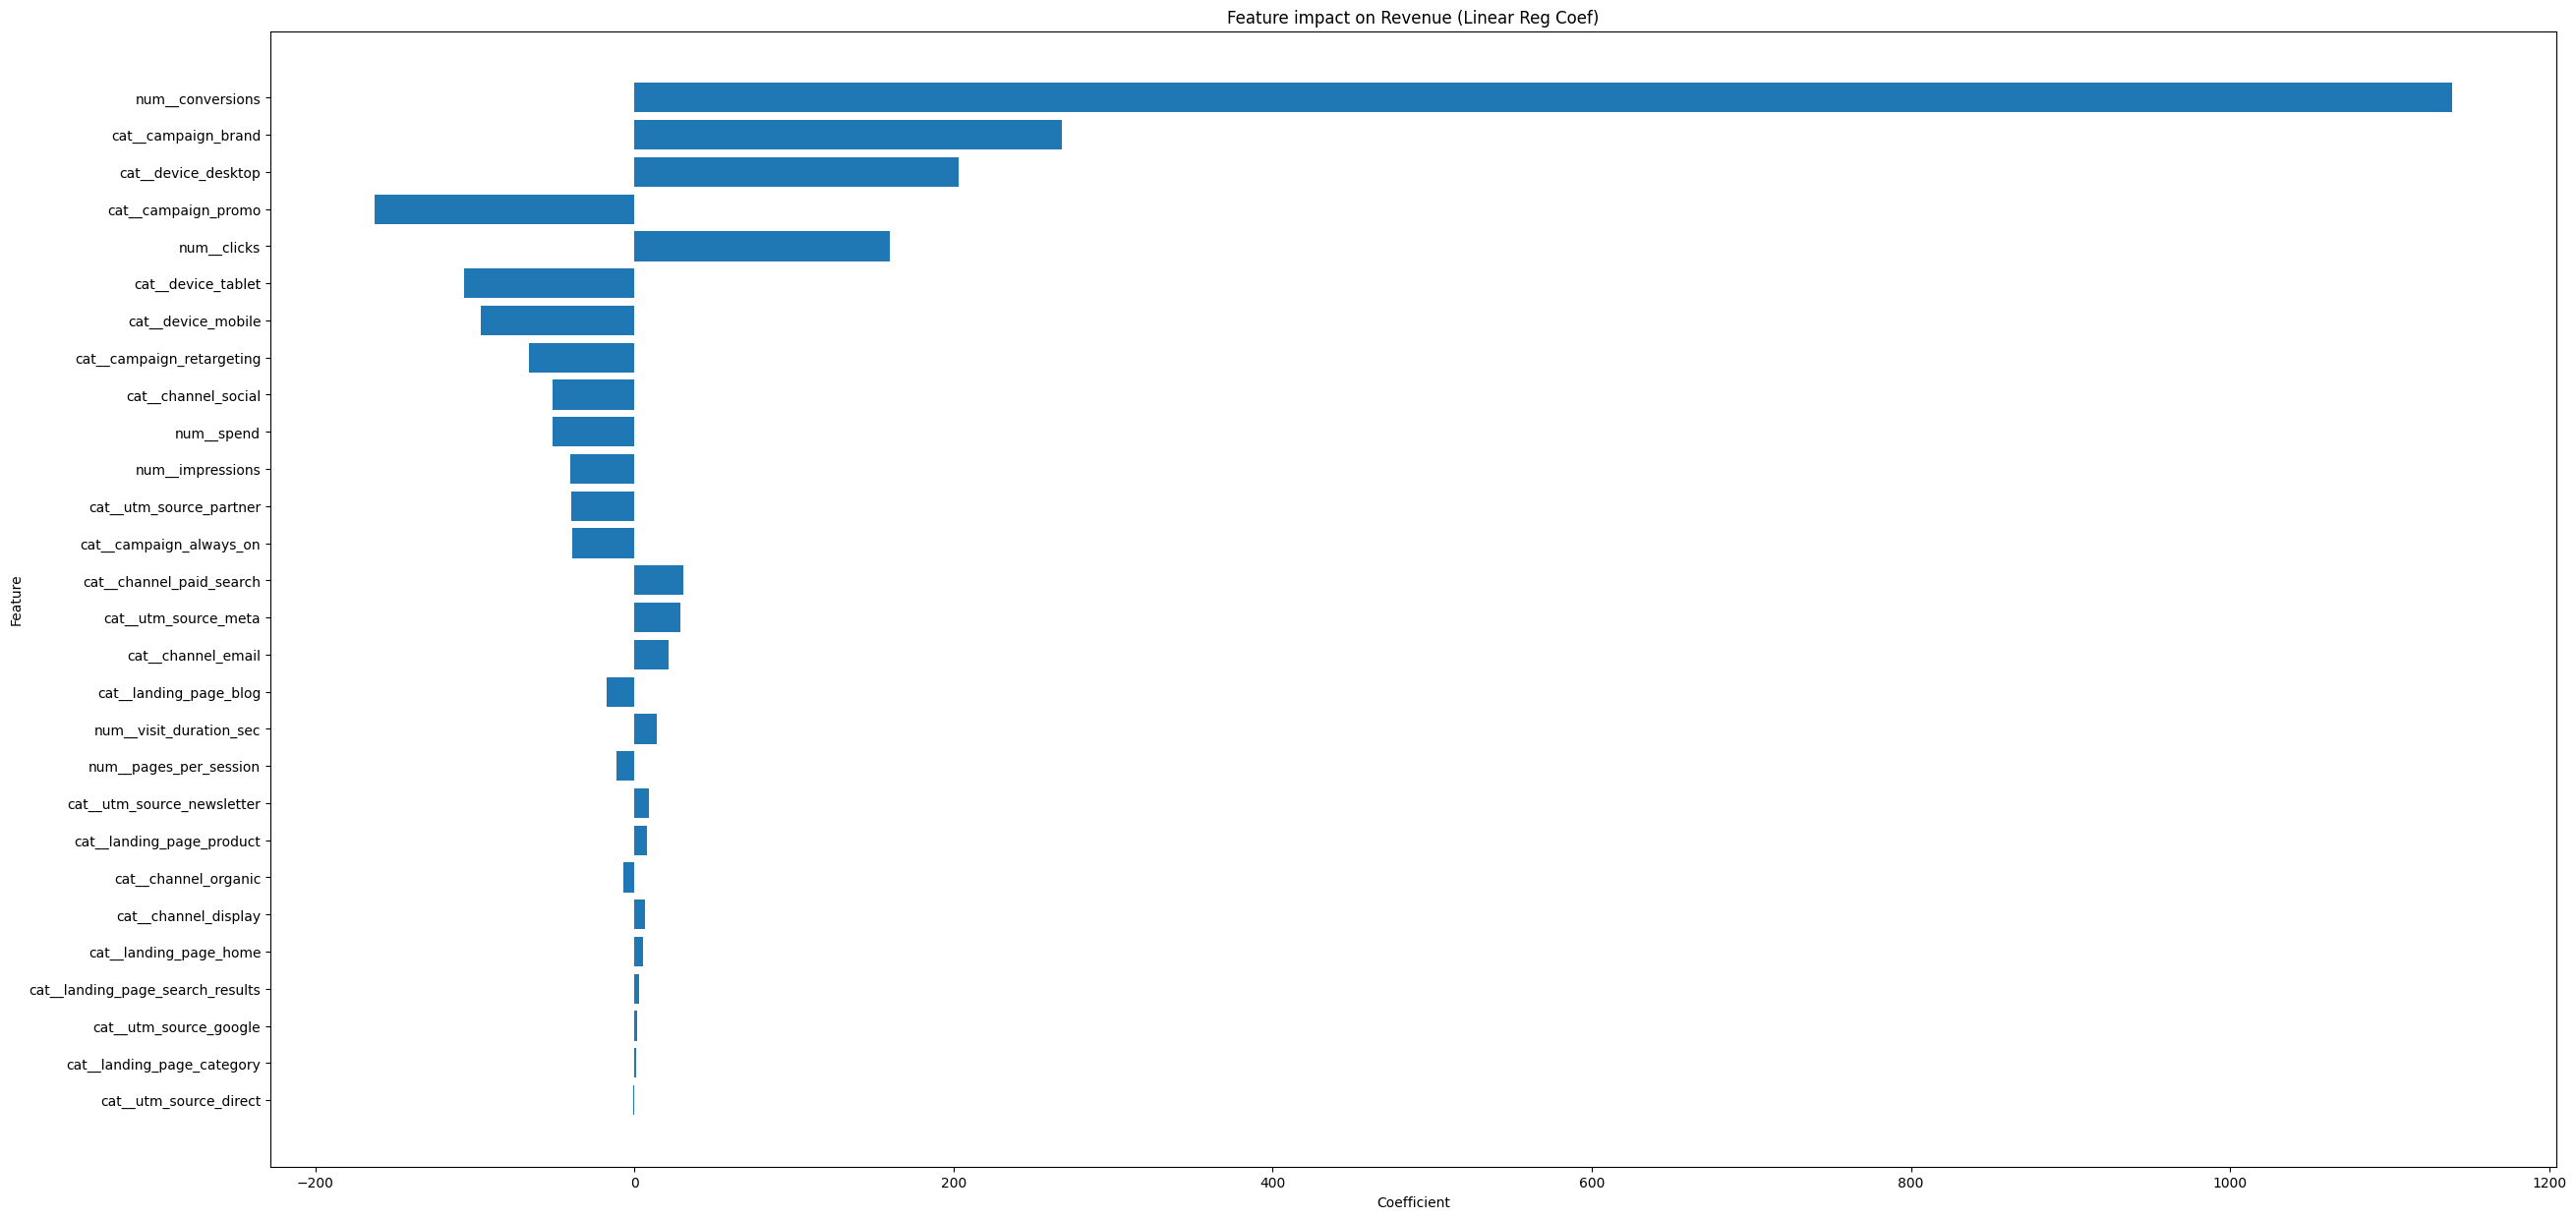

In [59]:
# 1. Extract feature names from the preprocessing step (Column transformer)
# This line retrieves the names of the features that were generated or transformed by the preprocessor step in the pipeline.
# `reg_pipeline.named_steps["preprocessor"]` accesses the `ColumnTransformer` object within the pipeline.
# `.get_feature_names_out()` is a method of `ColumnTransformer` that returns the names of the output features
# after all transformations (like OneHotEncoder creating new columns for categories and StandardScaler retaining original names for numerical features).
features_names = reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
#This will provide a list of all the features used by the model

# 2. Extract the learned coefficients from the model step (LinearRegression)
# This line accesses the trained `LinearRegression` model from the pipeline.
# `reg_pipeline.named_steps["model"]` accesses the `LinearRegression` object.
# `.coef_` is an attribute of a fitted `LinearRegression` model that contains the coefficient values
# for each feature in the order they were processed by the preprocessor.
coefs = reg_pipeline.named_steps["model"].coef_
#Get the learnt coefficients from the model using coef_
#This will provide a list of all the coefficients

# 3. Combine the feature names and coefficients into a DataFrame
# This step creates a pandas DataFrame to easily associate each feature name with its corresponding coefficient.
# A dictionary is created where 'feature' keys map to the `features_names` list and 'coef' keys map to the `coefs` array.
# This DataFrame makes it easier to inspect and sort the coefficients.
coef_df = pd.DataFrame (
    {
        "feature": features_names,
        "coef": coefs
    }
)
# Or coef_df = pd.DataFrame(coefs, index=features_names, columns=["coef"])



# Create a dataframe to pair features with their coeffients for easy viewing

# 4. Sort the dataframe by the absolute value of the coefficients
# A new column 'abs_coef' is created by taking the absolute value of the 'coef' column.
# This is done because the magnitude of a coefficient indicates the strength of its impact on the target variable,
# regardless of whether the impact is positive or negative.
coef_df['abs_coef'] = coef_df['coef'].abs()
#We need absolute because we are interested by magnitude of the effect, regardless of whether it is +ve or -ve

# The DataFrame is then sorted in descending order based on the 'abs_coef' column.
# This arranges the features from most impactful to least impactful.
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

#Sort the df by the absolute values to highlight the most important features
# `display()` is used to render the DataFrame in a user-friendly format in Colab.
display (coef_df)


# 5. Plot the coefficients for better visualization
# This section generates a horizontal bar plot to visually represent the coefficients.
# `plt.figure(figsize=(30, 15))` creates a new figure with a specified size for better readability of many bars.
plt.figure(figsize=(30, 15))
# `plt.barh()` creates horizontal bars. The y-axis represents the 'feature' names,
# and the x-axis represents the 'coef' values (the magnitude and direction of impact).
plt.barh(coef_df['feature'], coef_df['coef'])
# `plt.title()` sets the title of the plot.
plt.title("Feature impact on Revenue (Linear Reg Coef)")
# `plt.xlabel()` and `plt.ylabel()` set the labels for the x and y axes, respectively.
plt.xlabel('Coefficient')
plt.ylabel('Feature')
# `plt.gca().invert_yaxis()` inverts the y-axis so that the feature with the largest absolute coefficient
# (which is at the top after sorting) appears at the top of the plot.
plt.gca().invert_yaxis()
# `plt.show()` displays the generated plot.
plt.show()

A regression coefficient tells you:
If all other features stay the same, how much does revenue change when this feature
increases by 1.
Here, we see:
- Conversions = strongest driver - Brand campaigns perform best - Desktop users spend more -
Social and promo traffic bring less revenue - Clicks matter much more than impressions


# Overall Conclusion & Interpretation

### 1. Model Performance
* **R² Score: 0.957** — The model is extremely accurate, explaining **96%** of the variation in revenue.
* **MAE / RMSE:** The predictions are typically off by about **193€ (MAE)**, which is very low relative to the total revenue.

### 2. Key Drivers (Coefficients Analysis)

**A. The Dominant Factor: Conversions**
* **num__conversions (+1,139€):** This is by far the strongest predictor. For every additional conversion, revenue increases by ~1,139€. This indicates a high Average Order Value (AOV).
    * *Note:* Because this variable is so strong, it "absorbs" much of the impact from Spend and Impressions.

**B. Campaign & Brand Strategy**
* **Brand Campaigns (+267€):** "Brand" campaigns are highly effective, adding significant revenue over the baseline.
* **Promo Campaigns (-163€):** Promotional campaigns have a negative coefficient relative to the baseline. This likely means that while they might drive volume, the revenue *per transaction* is lower (due to discounts) compared to full-price Brand traffic.

**C. Device Performance**
* **Desktop (+203€):** Desktop users are much more valuable than the baseline.
* **Mobile (-96€) & Tablet (-106€):** Mobile and Tablet traffic generates significantly less revenue than Desktop. This suggests the checkout experience might be harder on mobile, or mobile users are just "browsing" rather than buying high-ticket items.

**D. Traffic Efficiency (Clicks vs. Spend)**
* **Clicks (+160€):** Driving traffic is positive.
* **Spend (-51€) & Impressions (-40€):** Interestingly, these are negative.
    * *Interpretation:* Since we are already accounting for Conversions and Clicks, "Spend" here represents **inefficiency**. If you increase Spend/Impressions *without* getting corresponding Clicks or Conversions, your Revenue prognosis actually goes down.

### 3. Marketing Recommendation
To maximize Revenue based on this model:
1.  **Prioritize Desktop traffic** over Mobile/Tablet where possible.
2.  **Focus on "Brand" keywords** rather than generic "Promo" campaigns which yield lower value.
3.  **Optimize for Efficiency:** High Spend/Impressions alone are negative signals. The goal isn't just to spend budget, but to convert that spend into **Clicks** and ultimately **Conversions**.